# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name: Sebha S
### Date: 29/09/2026

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [3]:
# TODO: shape, dtypes, missing value summary
df.shape


(48895, 16)

In [4]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [5]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [6]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [8]:
# TODO: duplicate check
df.duplicated().sum()


np.int64(0)

**Written notes — what did you find, and what looks suspicious?**


1. i found that the dataset contain numerical an categorical columns some missing values.i also checked the dataset of duplicate records

2. suspicious....> Zero values in price columns and extrimely high values in minimum_nights


---
## Part 2 — Missing Value Diagnosis & Treatment

In [9]:
# TODO: investigate missingness pattern(s) across columns
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [10]:
df['last_review'].isna().sum()

np.int64(10052)

In [11]:
df['reviews_per_month'].isna().sum()

np.int64(10052)

**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

I checked the missing values and compared them with other columns. Some look random (MCAR), while some may be related to other columns (MAR). A few may depend on the missing value itself (MNAR).



In [12]:
#TODO: apply your chosen treatment(s)
df = df.drop('last_review',axis = 1)

In [13]:
df =df.drop('reviews_per_month',axis = 1)

In [14]:
df = df.drop(['id','name','host_id','host_name'],axis = 1)

In [15]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

I used (dropna()) to remove rows containing missing values and maintain a clean dataset. However, this approach may discard useful observations and reduce the overall dataset size.


---
## Part 3 — Outlier Detection & Treatment

In [16]:
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

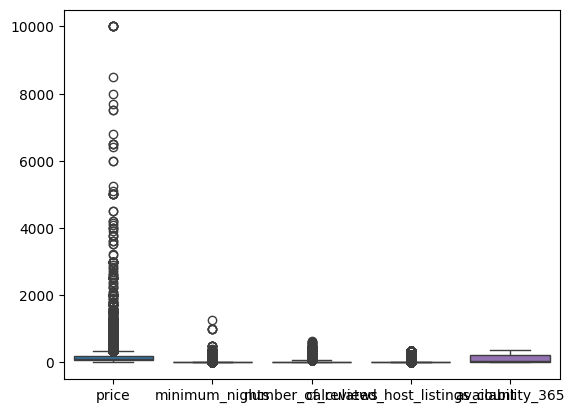

In [17]:
# TODO: detect outliers in at least two numeric columns
sns.boxplot(df[['price',
       'minimum_nights', 'number_of_reviews','calculated_host_listings_count',
       'availability_365']])
plt.show()

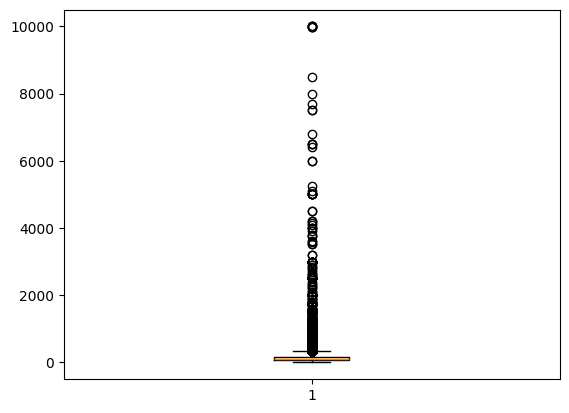

In [18]:
plt.boxplot(df['price'])
plt.show()

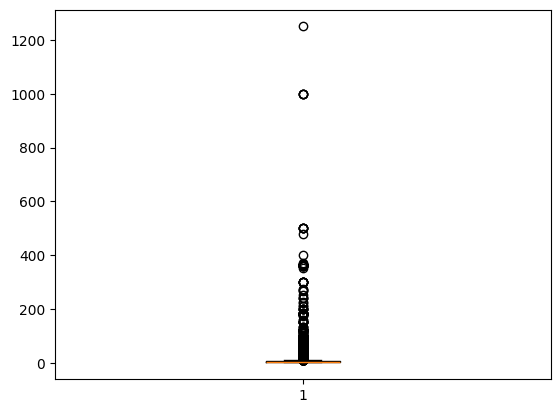

In [19]:
plt.boxplot(df['minimum_nights'])
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

I checked the outliers with other columns. Some values look like genuine listings, while some extreme values may be errors. I compared the price, minimum nights, and other details to identify unusual records.

In [20]:
from abc import update_abstractmethods
# TODO: apply treatment consistent with your judgment above
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
print(f'Q1={q1}\nq3 = {q3}')
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
print(f'IQR = {iqr}\nupper_bound = {upper_bound}\nlower_bound = {lower_bound}')


Q1=69.0
q3 = 175.0
IQR = 106.0
upper_bound = 334.0
lower_bound = -90.0


In [21]:
df.loc[df['price'] > upper_bound, 'price'] = upper_bound
df.loc[df['price'] < lower_bound, 'price'] = lower_bound
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0
...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,6,2


In [22]:
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)
print(f'Q1={q1}\nq3 = {q3}')
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
print(f'IQR = {iqr}\nupper_bound = {upper_bound}\nlower_bound = {lower_bound}')


Q1=1.0
q3 = 5.0
IQR = 4.0
upper_bound = 11.0
lower_bound = -5.0


In [23]:
df.loc[df['minimum_nights'] > upper_bound, 'minimum_nights'] = upper_bound
df.loc[df['minimum_nights'] < lower_bound, 'minimum_nights'] = lower_bound
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0
...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,6,2


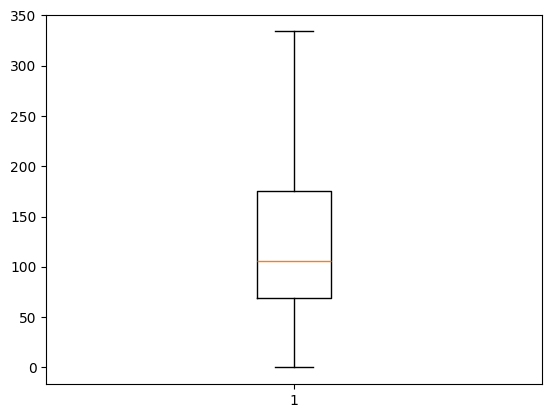

In [24]:
plt.boxplot(df['price'])
plt.show()

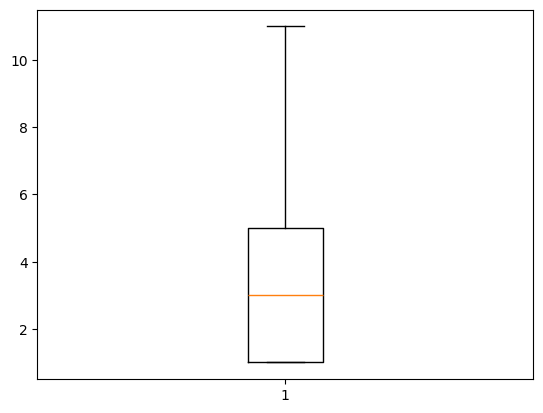

In [25]:
plt.boxplot(df['minimum_nights'])
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   calculated_host_listings_count  48895 non-null  int64  
 9   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 3.7+ MB


In [27]:
# TODO: encode categorical columns appropriately
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [28]:
frequency = df['neighbourhood'].value_counts()

df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [29]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,175,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,1545,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,2658,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,572,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,1117,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


In [30]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [31]:
# TODO: engineer at least two new features

from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Shared room', 'Private room', 'Entire home/apt']]
)
df['room_type']=encoder.fit_transform(df[['room_type']])

In [32]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [33]:
df=pd.get_dummies(df,prefix='group',dtype='int',drop_first=True)

In [34]:
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,group_Brooklyn,group_Manhattan,group_Queens,group_Staten Island
0,175,40.64749,-73.97237,1.0,149,1,9,6,365,1,0,0,0
1,1545,40.75362,-73.98377,2.0,225,1,45,2,355,0,1,0,0
2,2658,40.80902,-73.94190,1.0,150,3,0,1,365,0,1,0,0
3,572,40.68514,-73.95976,2.0,89,1,270,1,194,1,0,0,0
4,1117,40.79851,-73.94399,2.0,80,10,9,1,0,0,1,0,0


**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

First 4 columns are dropped they we id,name,host_id,host_name. They don't need to be present for prediction. other  object column were handled neighbourhood is handled by frequency encoder, room_type has ordinal data so ordinal encoding is done and for neighbourhood_group OneHotEncoding is done

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [35]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [36]:
# TODO: train/test split (before fitting anything)

# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()
# Missing value handling and removing Unnecessary columns
df=df.drop(['last_review','id','name','host_id','host_name','latitude','longitude'],axis=1)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [37]:
# Outlier Management
# PRICE
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

In [38]:
#Encoding:
# neighbourhood - frequency encoding,
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [39]:
# TODO: train/test split (before fitting anything)
# Seperate X and Y
x = df.drop('price',axis=1)
y = df['price']

# Train_test split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [40]:
numerical_columns = ['neighbourhood','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
nominal_columns = ['neighbourhood_group']
ordinal_columns = ['room_type']

In [41]:
numerical_pipeline = Pipeline([
    ('scalar',StandardScaler())
])

In [42]:
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

In [43]:
ordinal_pipeline = Pipeline([
    ('encoder',OrdinalEncoder(
        categories=[['Shared room', 'Private room', 'Entire home/apt']]
    ))
])

In [44]:
# Combine Pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numerical_columns),
    ('nominal',nominal_pipeline,nominal_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns)
])

In [45]:
# Fit and transform training data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

In [46]:
x_train.shape

(39116, 8)

In [47]:
x_train_preprocessed.shape

(39116, 11)

---
## Part 6 — Written Reflection

## — Written Reflection
1. The preprocessing decision that affected my model most was handling missing values and outliers.
    I know this because the model performed better after cleaning the data instead of using the raw data.

2. The data collection and preprocessing part would need to change.
    Live data needs to be collected and cleaned continuously before sending it to the model.

3. I didn’t delete every row because missing or unusual values don’t always mean the data is wrong.     
    Removing too many rows could reduce useful information and make the dataset smaller.
